# Closed-Loop Doppler Pre-Fit Residuals of Magellan using ATDF files

This notebook computes pre-fit residuals of Magellan using closed-loop Doppler observations of MGN, retrieved from ATDF files, as presented in Fig. 2 of the poster.

For a description of the general workflow to obtain pre-fit residuals see the [mro_doppler_prefits.ipynb](mro_doppler_prefits.ipynb) notebook.

## Required Data Files

The following data files are required to run the example.
All data files should be placed in a `data/MGN/` directory relative to this notebook.

### Kernels
The spacecraft trajectory kernel was retrieved from the [MGN SPICE Data Archive](https://naif.jpl.nasa.gov/pub/naif/MGN/kernels) in the `jplgrav_2006` directory:
- `spk`
  - `mgn_cycle4_grav.bsp`


It should be placed in `data/MGN/kernels/{kernel-type}/{file-name}`.

### ATDF and Ancillary Files
The ATDF and ancillary files are retrieved from the [PDS Geosciences Node](https://pds-geosciences.wustl.edu/mgn/mgn-v-rss-1-tracking-v1/mg_2601/):
- `TDF`
  - `2267276A.TDF`
  - `2276282A.TDF`
  - `2282288A.TDF`
  - `2288293A.TDF`
  - `2293299A.TDF`
  - `2299304A.TDF`
  - `2304310A.TDF`
- `ION`
  - `2245275A.ION`
  - `2275306A.ION`
- `TRO`
  - `2245275A.TRO`
  - `2275306A.TRO`

These should be placed in `data/MGN/{file-type}/{file-name}`.

In [1]:
from tudatpy.data_input.environment_data import spice

spice.load_standard_kernels()

In [2]:
from pathlib import Path

sc_name = "MGN"
sc_id = 18

mission_file_directory = Path(f"data/{sc_name}")
mission_output_directory = Path(f"output/{sc_name}")

In [3]:
kernels_directory = mission_file_directory / "kernels"

trajectory_kernels = [
    kernels_directory / "spk" / "mgn_cycle4_grav.bsp",
]

# Load trajectory kernels
for trajectory_file in trajectory_kernels:
    spice.load_kernel(trajectory_file.as_posix())


In [4]:
from tudatpy.data_input.tracking_data.atdf import read_atdf_data

atdf_file_directory = mission_file_directory / "TDF"
atdf_file_names = [
    "2267276A.TDF",
    "2276282A.TDF",
    "2282288A.TDF",
    "2288293A.TDF",
    "2293299A.TDF",
    "2299304A.TDF",
    "2304310A.TDF",
]

atdf_files = [atdf_file_directory / f for f in atdf_file_names]

tracking_data, tracking_supplementary_data = read_atdf_data(
    atdf_files,
    spacecraft_name=sc_name,
    range_two_way=False,
    count_time=[60.0],
    output_dir=(mission_output_directory / "atdf2ascii"),
)

                           Spacecraft ID   :  18                                 
                   Transponder Freq [Hz]   :  2297963786.0                       
                  Input Count time [sec]   :  [60.0]                             
                         File Start Time   :  23-Sep-1992 08:02:49.000000        
                           File End Time   :  02-Oct-1992 10:51:36.000000        
                           1-Way Doppler   :  False                              
                           2-Way Doppler   :  True                               
                           3-Way Doppler   :  True                               
                             1-Way Range   :  False                              
                             2-Way Range   :  False                              

Unpacking raw ATDF data    :  [████████████████████] 100% Time taken: 0 Hr: 0 Min: 11 Sec 

Extracting Ramp records    :  [████████████████████] 100% Time taken: 0 Hr: 0 Min: 0 Se

In [5]:
# Create default body settings for celestial bodies
from tudatpy.dynamics import environment_setup

bodies_to_create = [
    "Earth",
    "Sun",
    "Venus",
]
global_frame_origin = "SSB"
global_frame_orientation = "ECLIPJ2000"

start_time = min(min(t_data.epochs) for t_data in tracking_data) - 86400
end_time = max(max(t_data.epochs) for t_data in tracking_data) + 86400

body_settings = environment_setup.get_default_body_settings(
    bodies_to_create,
    global_frame_origin,
    global_frame_orientation,
)

# Modify Earth default settings
body_settings.get(
    "Earth"
).rotation_model_settings = environment_setup.rotation_model.gcrs_to_itrs(
    environment_setup.rotation_model.iau_2006,
    global_frame_orientation,
)
# since we defined the Earth rotation model as GCRS to ITRS, we need to set the gravity field reference frame to ITRS as well
body_settings.get("Earth").gravity_field_settings.associated_reference_frame = "ITRS"

body_settings.get(
    "Earth"
).shape_settings = environment_setup.shape.oblate_spherical_spice()
body_settings.get(
    "Earth"
).ground_station_settings = environment_setup.ground_station.dsn_stations()

In [6]:
from tudatpy.dynamics import environment_setup

body_settings.add_empty_settings(sc_name)

# Retrieve translational ephemeris from SPICE
body_settings.get(
    sc_name
).ephemeris_settings = environment_setup.ephemeris.interpolated_spice(
    start_time,
    end_time,
    10.0,
    global_frame_origin,
    global_frame_orientation,
)


In [7]:
# Create environment
bodies = environment_setup.create_system_of_bodies(body_settings)

bodies.get(sc_name).system_models.set_default_transponder_turnaround_ratio_function()

In [8]:
from tudatpy.estimation import observations

compressed_observations = observations.create_observation_collection_from_tracking_data(
    tracking_data, bodies
)
observations.set_tracking_supplementary_data_in_bodies(
    bodies, tracking_supplementary_data
)

In [9]:
from tudatpy.estimation import observable_models_setup, observations, observations_setup

relativistic_lt_correction = observable_models_setup.light_time_corrections.approximated_second_order_relativistic_light_time_correction(
    ["Sun"]
)

# the default seasonal model is already applied internally, here we only need to provide the monthly adjustment files
tro_file_names = ["2245275A.TRO", "2275306A.TRO"]
tro_files = [(mission_file_directory / "TRO" / f).as_posix() for f in tro_file_names]
tropospheric_lt_correction = observable_models_setup.light_time_corrections.dsn_tabulated_tropospheric_light_time_correction(
    tro_files,
)

ion_file_names = ["2245275A.ION", "2275306A.ION"]
ion_files = [(mission_file_directory / "ION" / f).as_posix() for f in ion_file_names]
spacecraft_name_per_id = {sc_id: sc_name}
ionospheric_lt_correction = observable_models_setup.light_time_corrections.dsn_tabulated_ionospheric_light_time_correction(
    ion_files, spacecraft_name_per_id
)

solar_corona_lt_correction = observable_models_setup.light_time_corrections.inverse_power_series_solar_corona_light_time_correction()

doppler_lt_corrections = [
    relativistic_lt_correction,
    tropospheric_lt_correction,
    ionospheric_lt_correction,
    solar_corona_lt_correction,
]


In [10]:
from tudatpy.estimation.observable_models_setup import model_settings

doppler_link_definitions = compressed_observations.link_definitions_per_observable[
    model_settings.ObservableType.dsn_n_way_averaged_doppler_type
]
observable_model_settings = [
    model_settings.dsn_n_way_doppler_averaged(link_definition, doppler_lt_corrections)
    for link_definition in doppler_link_definitions
]

observation_simulators = (
    observations_setup.observations_simulation_settings.create_observation_simulators(
        observable_model_settings, bodies
    )
)

In [11]:
# Compute and set residuals in the compressed observation collection
observations.compute_residuals_and_dependent_variables(
    compressed_observations, observation_simulators, bodies
)


Text(0, 0.5, 'Doppler residuals [Hz]')

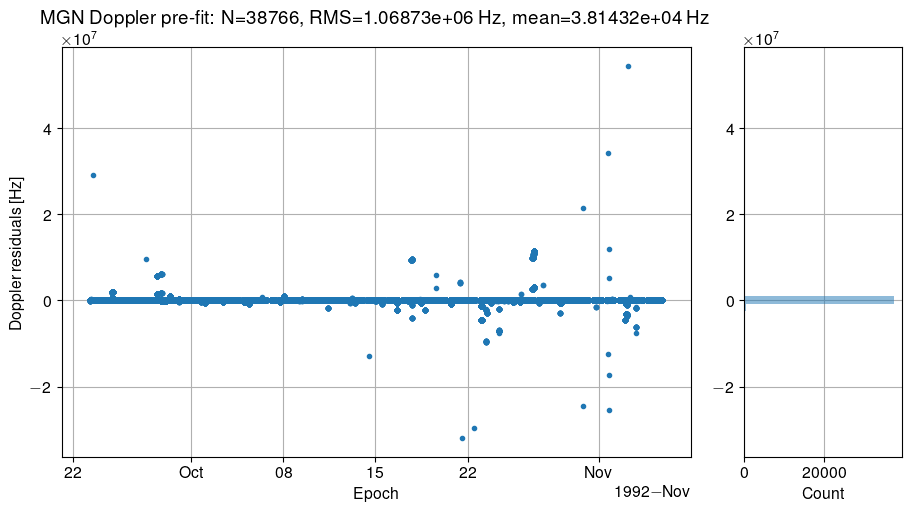

In [12]:
import numpy as np
from matplotlib import pyplot as plt
from tudatpy.astro.time_representation import DateTime

import plotting_utils as plt_utils

prefit_observation_times_dt = [
    DateTime.from_epoch(t).to_python_datetime()
    for t in compressed_observations.get_concatenated_observation_times()
]
prefit_residuals = compressed_observations.get_concatenated_residuals()
prefit_N_obs = len(prefit_residuals)
prefit_RMS = np.sqrt(np.square(prefit_residuals).mean())
prefit_mean = prefit_residuals.mean()


fig, (ax, ax_hist) = plt_utils.create_residual_timeseries_with_histogram_figure()

ax.plot(
    prefit_observation_times_dt,
    prefit_residuals,
    ".",
)
ax_hist.hist(
    prefit_residuals,
    bins=50,
    alpha=0.5,
    orientation="horizontal",
)

ax.set_title(
    f"{sc_name} Doppler pre-fit: N={prefit_N_obs}, RMS={prefit_RMS:.5e} Hz, mean={prefit_mean:.5e} Hz"
)

ax.set_ylabel("Doppler residuals [Hz]")


In [13]:
# create a new observation collection to keep all original observations
filtered_observations = observations.create_new_observation_collection(
    compressed_observations
)

residual_threshold = 0.1  # abs(residuals) > 0.1 Hz
filter_residuals = observations.observations_processing.observation_filter(
    observations.observations_processing.ObservationFilterType.residual_filtering,
    residual_threshold,
)

filtered_observations.filter_observations(filter_residuals)
filtered_observations.remove_empty_observation_sets()


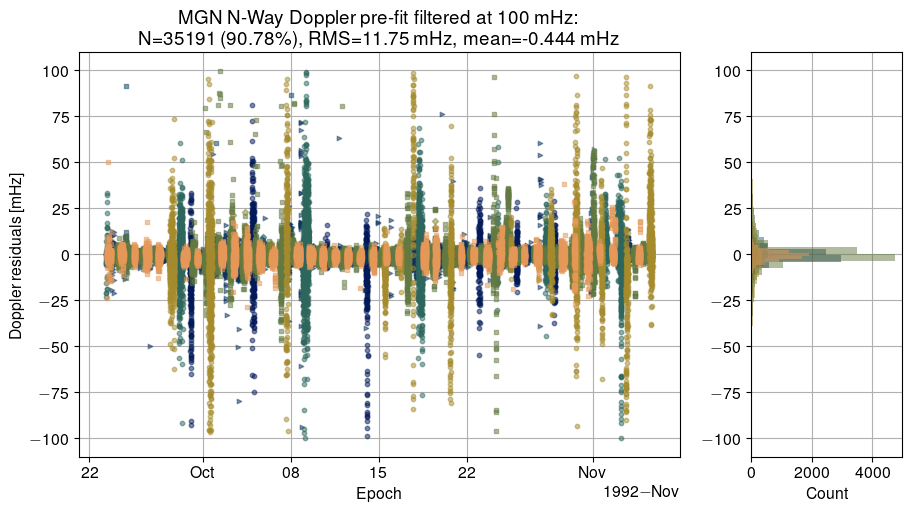

In [14]:
with plt.rc_context(
    {
        "axes.prop_cycle": plt_utils.default_residuals_color_cycle(15),
    }
):
    fig, (ax, ax_hist) = (
        plt_utils.plot_doppler_residuals_with_histogram_link_end_grouped(
            filtered_observations, add_legend=False
        )
    )

plt_utils.set_doppler_residual_statistic_title(
    ax,
    residual_threshold,
    filtered_observations,
    compressed_observations,
    mission_name=sc_name,
)
plt_utils.save_figure(
    fig,
    mission_output_directory
    / f"{sc_name}_doppler_prefits_filtered_{residual_threshold:.2f}Hz.png",
)

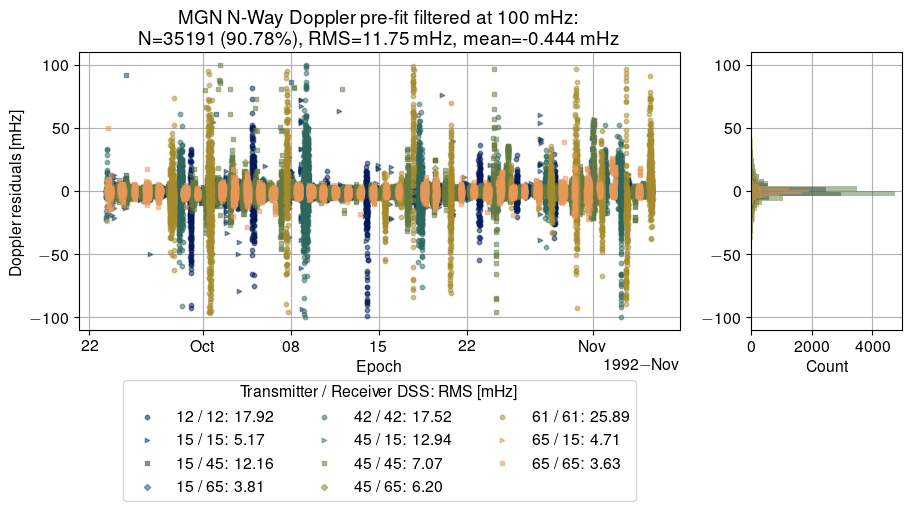

In [15]:
with plt.rc_context(
    {
        "axes.prop_cycle": plt_utils.default_residuals_color_cycle(15),
    }
):
    fig2, (ax, ax_hist) = (
        plt_utils.plot_doppler_residuals_with_histogram_link_end_grouped(
            filtered_observations
        )
    )

plt_utils.set_doppler_residual_statistic_title(
    ax,
    residual_threshold,
    filtered_observations,
    compressed_observations,
    mission_name=sc_name,
)

ax.legend(
    ncols=3,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    title="Transmitter / Receiver DSS: RMS [mHz]",
)

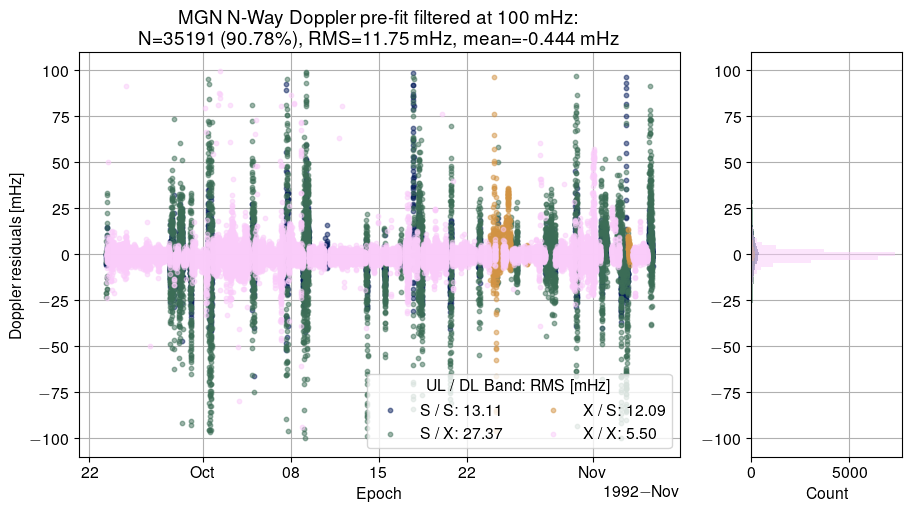

In [16]:
import numpy as np
from tudatpy.astro.time_representation import DateTime
from tudatpy.estimation.observations_setup import ancillary_settings

band_configs = [
    (
        ancillary_settings.FrequencyBands.s_band,
        ancillary_settings.FrequencyBands.s_band,
    ),
    (
        ancillary_settings.FrequencyBands.s_band,
        ancillary_settings.FrequencyBands.x_band,
    ),
    (
        ancillary_settings.FrequencyBands.x_band,
        ancillary_settings.FrequencyBands.s_band,
    ),
    (
        ancillary_settings.FrequencyBands.x_band,
        ancillary_settings.FrequencyBands.x_band,
    ),
]

band_to_string = {
    ancillary_settings.FrequencyBands.s_band: "S",
    ancillary_settings.FrequencyBands.x_band: "X",
}

concatenated_epochs_per_band = {bands: [] for bands in band_configs}
concatenated_residuals_per_band = {bands: [] for bands in band_configs}

for single_obs_set in filtered_observations.get_single_observation_sets():
    parsed_filtered_observation_times_dt = [
        DateTime.from_epoch_time_object(t).to_python_datetime()
        for t in single_obs_set.observation_times
    ]
    parsed_filtered_residuals = (
        np.array(single_obs_set.residuals) * 1000
    )  # convert to mHz
    obs_bands = tuple(
        single_obs_set.ancillary_settings.get_float_list_settings(
            ancillary_settings.ObservationAncillarySimulationVariable.frequency_bands
        )
    )

    concatenated_epochs_per_band[obs_bands].extend(parsed_filtered_observation_times_dt)
    concatenated_residuals_per_band[obs_bands].extend(parsed_filtered_residuals)

with plt.rc_context(
    {
        "axes.prop_cycle": plt_utils.default_residuals_color_cycle(4),
    }
):
    fig, (ax, ax_hist) = plt_utils.create_residual_timeseries_with_histogram_figure(
        figsize=plt_utils.POSTER_FIG_SIZE
    )
    for obs_bands, residuals in concatenated_residuals_per_band.items():
        label = f"{band_to_string[obs_bands[0]]} / {band_to_string[obs_bands[1]]}: {np.sqrt(np.square(np.array(residuals)).mean()):.2f}"

        ax.scatter(
            concatenated_epochs_per_band[obs_bands],
            np.array(residuals),
            s=10,
            alpha=0.5,
            label=label,
        )

        ax_hist.hist(
            np.array(residuals),
            bins=100,
            orientation="horizontal",
            alpha=0.5,
        )

ax.legend(
    title="UL / DL Band: RMS [mHz]",
    loc="lower right",
    ncols=2,
)

ax.set_ylabel("Doppler residuals [mHz]")

plt_utils.set_doppler_residual_statistic_title(
    ax,
    residual_threshold,
    filtered_observations,
    compressed_observations,
    mission_name=sc_name,
)

plt_utils.save_figure(
    fig,
    mission_output_directory
    / f"{sc_name}_doppler_prefits_filtered_{residual_threshold:.2f}Hz_bands.png",
)
